# Thực nghiệm so sánh: Knowledge Distillation (ConvNeXt → MobileNetV3) vs. Baseline MobileNetV3
## Bài toán: Phân loại Đồng phục (Uniform / Non_Uniform)

Notebook này thực hiện 2 thực nghiệm trên cùng một dataset đã qua tiền xử lý (YOLO detect person → crop nửa thân trên):

1. **Baseline**: Train MobileNetV3-Large trực tiếp trên nhãn thật (hard label).
2. **Knowledge Distillation**: Train teacher ConvNeXt-Tiny → dùng soft label từ teacher để distill vào MobileNetV3-Large (response-based KD, Hinton et al. 2015).

Toàn bộ hyperparameter được tách riêng ở **Block Config** bên dưới — chỉ cần sửa ở đó, không cần đụng vào logic training.

> **Dùng lại cho thẻ sinh viên**: chỉ cần đổi `DATA_ROOT`, `CLASS_NAMES` trong Config (ví dụ `["No_Card", "Card"]`) và trỏ đúng thư mục dataset thẻ — toàn bộ pipeline còn lại giữ nguyên.

**Giả định cấu trúc thư mục dataset** (dạng `ImageFolder` chuẩn của torchvision):
```
DATA_ROOT/
  train/Uniform/*.jpg   train/Non_Uniform/*.jpg
  val/Uniform/*.jpg     val/Non_Uniform/*.jpg
  test/Uniform/*.jpg    test/Non_Uniform/*.jpg
```
Nếu cấu trúc thực tế khác (ví dụ có file `.csv` chứa nhãn), chỉnh lại phần `Dataset & DataLoader` — phần Config vẫn giữ nguyên.


## 1. Imports

In [1]:
import os
import copy
import json
import random
import time
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.11.0+cu128
CUDA available: True


## 2. Block Config — CHỈNH TẤT CẢ THÔNG SỐ Ở ĐÂY

Mọi hyperparameter, đường dẫn, lựa chọn model và augmentation đều nằm trong `CFG`.
Không cần sửa gì ở các block phía dưới trừ khi muốn đổi logic.


In [23]:
@dataclass
class Config:
    # ---------------- Dữ liệu ----------------
    DATA_ROOT: str = "./Dataset_train_uniform_final"          # thư mục gốc chứa train/val/test
    CLASS_NAMES: tuple = ("Non_Uniform", "Uniform")  # thứ tự phải khớp ImageFolder (alphabet)
    IMG_SIZE: int = 224
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 4

    # ---------------- Augmentation (xem block 3 để hiểu lý do) ----------------
    AUG_RANDOM_RESIZED_CROP_SCALE: tuple = (0.85, 1.0)   # crop nhẹ, vì ảnh đã được YOLO crop sát người
    AUG_HFLIP_PROB: float = 0.0          # đặt 0.0 nếu logo/đồng phục có tính bất đối xứng rõ (chữ 1 bên)
    AUG_ROTATION_DEG: int = 8            # mô phỏng camera nghiêng nhẹ
    AUG_COLOR_JITTER_BRIGHTNESS: float = 0.25
    AUG_COLOR_JITTER_CONTRAST: float = 0.25
    AUG_COLOR_JITTER_SATURATION: float = 0.15
    AUG_COLOR_JITTER_HUE: float = 0.02   # giữ rất nhỏ vì màu sắc là tín hiệu phân biệt chính của đồng phục
    AUG_PERSPECTIVE_PROB: float = 0.2    # mô phỏng góc quay camera giám sát
    AUG_PERSPECTIVE_DISTORTION: float = 0.15
    AUG_GAUSSIAN_BLUR_PROB: float = 0.15 # mô phỏng ảnh CCTV hơi mờ / chuyển động
    AUG_RANDOM_ERASING_PROB: float = 0.25  # mô phỏng người bị che khuất một phần (occlusion)
    AUG_RANDOM_ERASING_SCALE: tuple = (0.02, 0.12)

    NORM_MEAN: tuple = (0.485, 0.456, 0.406)  # thống kê ImageNet (model pretrained trên ImageNet)
    NORM_STD: tuple = (0.229, 0.224, 0.225)

    # ---------------- Model ----------------
    STUDENT_MODEL_NAME: str = "mobilenetv3_large_100"   # timm model name
    TEACHER_MODEL_NAME: str = "convnext_tiny"            # timm model name
    PRETRAINED: bool = True
    STUDENT_UNFREEZE_LAST_N_BLOCKS: int = 3   # partial fine-tuning: chỉ mở khóa N block cuối + classifier head
    TEACHER_UNFREEZE_LAST_N_BLOCKS: int = 2

    # ---------------- Optimizer / Scheduler ----------------
    OPTIMIZER: str = "adamw"
    LR_STUDENT_BASELINE: float = 1e-5
    LR_STUDENT_KD: float = 1e-5      # cố tình để CÙNG giá trị với baseline để so sánh công bằng
    LR_TEACHER: float = 1e-5
    WEIGHT_DECAY: float = 1e-4      # dùng CHUNG cho mọi pipeline 
    LABEL_SMOOTHING: float = 0.1
    SCHEDULER: str = "cosine"        # cosine annealing
    WARMUP_EPOCHS: int = 2

    # ---------------- Training ----------------
    EPOCHS_TEACHER: int = 20
    EPOCHS_BASELINE: int = 30
    EPOCHS_KD: int = 30
    EARLY_STOPPING_PATIENCE: int = 7
    CHECKPOINT_METRIC: str = "val_acc"   # "val_acc" hoặc "val_loss" — DÙNG CHUNG cho mọi pipeline

    # ---------------- Knowledge Distillation ----------------
    KD_TEMPERATURE: float = 4.0
    KD_ALPHA: float = 0.5   # trọng số giữa soft loss (KD) và hard loss (CE với nhãn thật)
    KD_LOSS_TYPE: str = "response"  # "response" (logit-only) hoặc "response+feature" (thêm feature matching)
    KD_FEATURE_LOSS_WEIGHT: float = 0.3  # chỉ dùng nếu KD_LOSS_TYPE = "response+feature"

    # ---------------- Reproducibility / Multi-seed ----------------
    SEEDS: tuple = (42,)   # đổi thành (42, 1, 7) để chạy nhiều seed và lấy mean ± std cho báo cáo
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

    # ---------------- Output ----------------
    OUTPUT_DIR: str = "./runs/uniform_kd_experiment"


CFG = Config()
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print(json.dumps(asdict(CFG), indent=2, default=str))


{
  "DATA_ROOT": "./Dataset_train_uniform_final",
  "CLASS_NAMES": [
    "Non_Uniform",
    "Uniform"
  ],
  "IMG_SIZE": 224,
  "BATCH_SIZE": 32,
  "NUM_WORKERS": 4,
  "AUG_RANDOM_RESIZED_CROP_SCALE": [
    0.85,
    1.0
  ],
  "AUG_HFLIP_PROB": 0.0,
  "AUG_ROTATION_DEG": 8,
  "AUG_COLOR_JITTER_BRIGHTNESS": 0.25,
  "AUG_COLOR_JITTER_CONTRAST": 0.25,
  "AUG_COLOR_JITTER_SATURATION": 0.15,
  "AUG_COLOR_JITTER_HUE": 0.02,
  "AUG_PERSPECTIVE_PROB": 0.2,
  "AUG_PERSPECTIVE_DISTORTION": 0.15,
  "AUG_GAUSSIAN_BLUR_PROB": 0.15,
  "AUG_RANDOM_ERASING_PROB": 0.25,
  "AUG_RANDOM_ERASING_SCALE": [
    0.02,
    0.12
  ],
  "NORM_MEAN": [
    0.485,
    0.456,
    0.406
  ],
  "NORM_STD": [
    0.229,
    0.224,
    0.225
  ],
  "STUDENT_MODEL_NAME": "mobilenetv3_large_100",
  "TEACHER_MODEL_NAME": "convnext_tiny",
  "PRETRAINED": true,
  "STUDENT_UNFREEZE_LAST_N_BLOCKS": 3,
  "TEACHER_UNFREEZE_LAST_N_BLOCKS": 2,
  "OPTIMIZER": "adamw",
  "LR_STUDENT_BASELINE": 1e-05,
  "LR_STUDENT_KD": 1e-05,
  "L

## 3. Augmentation — thiết kế riêng cho bài toán nhận diện đồng phục

Nguyên tắc chọn augmentation ở đây khác với augmentation "chuẩn ImageNet":

- **Không** dùng crop mạnh (scale thấp) vì ảnh đầu vào đã được YOLO crop sát vùng thân trên — crop thêm dễ cắt mất logo/cổ áo, vốn là vùng thông tin quan trọng nhất.
- **Color jitter vừa phải, hue gần như giữ nguyên**: màu sắc là tín hiệu phân biệt chính giữa Uniform/Non-Uniform, jitter quá mạnh (đặc biệt là hue) có thể biến một áo xanh navy đồng phục thành trông giống áo khác màu — phản tác dụng.
- **RandomPerspective + rotation nhẹ**: mô phỏng góc camera giám sát (thường đặt cao, chếch xuống) chứ không phải ảnh chụp thẳng.
- **GaussianBlur xác suất thấp**: mô phỏng ảnh CCTV chất lượng thấp/chuyển động, giúp model không quá nhạy với ảnh nét cao.
- **RandomErasing (cutout)**: mô phỏng occlusion — người đứng che nhau trong khu vực đông người, giúp model không phụ thuộc vào một vùng ảnh cố định để ra quyết định.
- **Horizontal flip có thể tắt** qua config nếu logo có tính bất đối xứng rõ (chữ/huy hiệu chỉ ở một bên ngực).

Augmentation cho `val`/`test` chỉ resize + normalize, không augment, để đánh giá phản ánh đúng phân phối dữ liệu thật.


In [14]:
def build_transforms(cfg: Config):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(
            cfg.IMG_SIZE, scale=cfg.AUG_RANDOM_RESIZED_CROP_SCALE
        ),
        transforms.RandomHorizontalFlip(p=cfg.AUG_HFLIP_PROB),
        transforms.RandomRotation(cfg.AUG_ROTATION_DEG),
        transforms.RandomPerspective(
            distortion_scale=cfg.AUG_PERSPECTIVE_DISTORTION,
            p=cfg.AUG_PERSPECTIVE_PROB,
        ),
        transforms.ColorJitter(
            brightness=cfg.AUG_COLOR_JITTER_BRIGHTNESS,
            contrast=cfg.AUG_COLOR_JITTER_CONTRAST,
            saturation=cfg.AUG_COLOR_JITTER_SATURATION,
            hue=cfg.AUG_COLOR_JITTER_HUE,
        ),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=cfg.AUG_GAUSSIAN_BLUR_PROB,
        ),
        transforms.ToTensor(),
        transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD),
        transforms.RandomErasing(
            p=cfg.AUG_RANDOM_ERASING_PROB,
            scale=cfg.AUG_RANDOM_ERASING_SCALE,
        ),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD),
    ])

    return train_tf, eval_tf


## 4. Dataset & DataLoader

In [15]:
def build_dataloaders(cfg: Config):
    train_tf, eval_tf = build_transforms(cfg)

    train_ds = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "train"), transform=train_tf)
    val_ds   = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "val"),   transform=eval_tf)
    test_ds  = datasets.ImageFolder(os.path.join(cfg.DATA_ROOT, "test"),  transform=eval_tf)

    assert tuple(train_ds.classes) == tuple(cfg.CLASS_NAMES), (
        f"Thứ tự lớp không khớp! ImageFolder đọc được {train_ds.classes}, "
        f"nhưng CFG.CLASS_NAMES = {cfg.CLASS_NAMES}. Sửa CFG.CLASS_NAMES cho khớp."
    )

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                               num_workers=cfg.NUM_WORKERS, pin_memory=True)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Classes: {train_ds.classes}")
    return train_loader, val_loader, test_loader


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## 5. Model — Teacher (ConvNeXt-Tiny) & Student (MobileNetV3-Large)

Dùng `timm` để tạo cả hai model từ pretrained ImageNet weights, rồi áp dụng **partial fine-tuning**:
đóng băng phần lớn backbone, chỉ mở khóa N block cuối + classifier head — giống hyperparameter đã dùng ở
pipeline trước, giữ nguyên để so sánh công bằng.


In [16]:
def _freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False


def _unfreeze_last_n_blocks(model, n_blocks: int):
    """Mở khóa N block cuối cùng của backbone + toàn bộ classifier head.
    timm models thường expose .get_classifier() và một list các stage/block;
    cách an toàn nhất là mở khóa theo tên tham số ở các layer cuối."""
    param_names = [name for name, _ in model.named_parameters()]
    # Luôn mở khóa classifier / head
    for name, p in model.named_parameters():
        if any(k in name.lower() for k in ["classifier", "head", "fc"]):
            p.requires_grad = True

    if n_blocks <= 0:
        return

    # Lấy các block/stage theo thứ tự xuất hiện, mở khóa n_blocks cuối
    block_prefixes = []
    for name, _ in model.named_parameters():
        parts = name.split(".")
        if len(parts) >= 2:
            prefix = ".".join(parts[:2])
            if prefix not in block_prefixes:
                block_prefixes.append(prefix)

    for prefix in block_prefixes[-n_blocks:]:
        for name, p in model.named_parameters():
            if name.startswith(prefix):
                p.requires_grad = True


def build_student(cfg: Config, num_classes: int):
    model = timm.create_model(cfg.STUDENT_MODEL_NAME, pretrained=cfg.PRETRAINED,
                               num_classes=num_classes)
    _freeze_all(model)
    _unfreeze_last_n_blocks(model, cfg.STUDENT_UNFREEZE_LAST_N_BLOCKS)
    return model.to(cfg.DEVICE)


def build_teacher(cfg: Config, num_classes: int):
    model = timm.create_model(cfg.TEACHER_MODEL_NAME, pretrained=cfg.PRETRAINED,
                               num_classes=num_classes)
    _freeze_all(model)
    _unfreeze_last_n_blocks(model, cfg.TEACHER_UNFREEZE_LAST_N_BLOCKS)
    return model.to(cfg.DEVICE)


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


## 6. Optimizer / Scheduler / Loss dùng chung

In [17]:
def build_optimizer(cfg: Config, model, lr: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if cfg.OPTIMIZER.lower() == "adamw":
        return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=cfg.WEIGHT_DECAY)
    raise ValueError(f"Optimizer {cfg.OPTIMIZER} chưa được hỗ trợ, tự thêm nếu cần.")


def build_scheduler(cfg: Config, optimizer, epochs: int, steps_per_epoch: int):
    total_steps = epochs * steps_per_epoch
    warmup_steps = cfg.WARMUP_EPOCHS * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


hard_loss_fn = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)


def kd_loss_fn(student_logits, teacher_logits, targets, temperature, alpha):
    """Response-based KD loss (Hinton et al., 2015):
    L = alpha * CE(hard label) + (1 - alpha) * T^2 * KL(soft student || soft teacher)"""
    hard_loss = F.cross_entropy(student_logits, targets, label_smoothing=CFG.LABEL_SMOOTHING)

    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction="batchmean") * (temperature ** 2)

    return alpha * hard_loss + (1 - alpha) * soft_loss, hard_loss.item(), soft_loss.item()


## 7. Vòng lặp Train / Eval dùng chung

Cùng một hàm `run_epoch` cho cả 3 pipeline (teacher, baseline, KD) để đảm bảo logic đo lường
(accuracy, checkpoint selection) hoàn toàn nhất quán — tránh lặp lại vấn đề "tiêu chí chọn checkpoint
khác nhau giữa các pipeline" đã gặp trước đây.


In [18]:
def run_epoch(model, loader, optimizer, scheduler, cfg: Config,
               teacher=None, mode="train"):
    """mode: 'train' (baseline, CE loss) | 'train_kd' (KD loss) | 'eval'"""
    is_train = mode in ("train", "train_kd")
    model.train() if is_train else model.eval()
    if teacher is not None:
        teacher.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(cfg.DEVICE), y.to(cfg.DEVICE)

            if mode == "train_kd":
                with torch.no_grad():
                    teacher_logits = teacher(x)
                student_logits = model(x)
                loss, _, _ = kd_loss_fn(student_logits, teacher_logits, y,
                                        cfg.KD_TEMPERATURE, cfg.KD_ALPHA)
                logits = student_logits
            else:
                logits = model(x)
                loss = hard_loss_fn(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model(model, train_loader, val_loader, cfg: Config, lr: float, epochs: int,
                 teacher=None, run_name="model"):
    optimizer = build_optimizer(cfg, model, lr)
    scheduler = build_scheduler(cfg, optimizer, epochs, len(train_loader))
    mode = "train_kd" if teacher is not None else "train"

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_metric = -np.inf if cfg.CHECKPOINT_METRIC == "val_acc" else np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, scheduler, cfg,
                                           teacher=teacher, mode=mode)
        val_loss, val_acc = run_epoch(model, val_loader, None, None, cfg, mode="eval")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        current_metric = val_acc if cfg.CHECKPOINT_METRIC == "val_acc" else -val_loss
        improved = current_metric > best_metric
        if improved:
            best_metric = current_metric
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
              f"({time.time()-t0:.1f}s){' *' if improved else ''}")

        if patience_counter >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"[{run_name}] Early stopping tại epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    ckpt_path = os.path.join(cfg.OUTPUT_DIR, f"{run_name}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"[{run_name}] Đã lưu best checkpoint tại: {ckpt_path}")
    return model, history


## 8. Đánh giá (Accuracy / Precision / Recall / F1 / Confusion Matrix)

In [19]:
@torch.no_grad()
def evaluate_model(model, loader, cfg: Config, class_names):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(cfg.DEVICE)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )
    cm = confusion_matrix(all_targets, all_preds)
    report = classification_report(all_targets, all_preds, target_names=class_names, zero_division=0)

    return {
        "accuracy": acc, "precision_macro": precision,
        "recall_macro": recall, "f1_macro": f1,
        "confusion_matrix": cm, "report": report,
    }


def plot_confusion_matrices(results_dict, class_names):
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, res) in zip(axes, results_dict.items()):
        cm = res["confusion_matrix"]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{name}\nacc={res['accuracy']:.3f}  f1={res['f1_macro']:.3f}")
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.show()


def plot_training_curves(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        axes[0].plot(h["val_loss"], label=name)
        axes[1].plot(h["val_acc"], label=name)
    axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()


## 9. Chạy thực nghiệm

Chạy tuần tự: (1) Teacher ConvNeXt → (2) Baseline MobileNetV3 → (3) KD MobileNetV3.
Nếu `CFG.SEEDS` có nhiều hơn 1 giá trị, toàn bộ pipeline sẽ lặp lại cho mỗi seed và kết quả cuối
được tổng hợp thành mean ± std ở block cuối — nên dùng khi cần con số đáng tin cậy cho báo cáo
(dataset test hiện khá nhỏ nên kết quả 1 lần chạy có thể dao động).


In [24]:
all_results = []   # mỗi phần tử: {seed, baseline_metrics, kd_metrics, teacher_metrics, histories}

for seed in CFG.SEEDS:
    print(f"\n{'='*70}\nSEED = {seed}\n{'='*70}")
    set_seed(seed)

    train_loader, val_loader, test_loader = build_dataloaders(CFG)
    num_classes = len(CFG.CLASS_NAMES)

    # ---------- 1) Train Teacher (ConvNeXt) ----------
    print("\n--- Training Teacher (ConvNeXt) ---")
    teacher = build_teacher(CFG, num_classes)
    trainable, total = count_trainable_params(teacher)
    print(f"Teacher trainable params: {trainable:,} / {total:,}")
    teacher, teacher_hist = train_model(
        teacher, train_loader, val_loader, CFG,
        lr=CFG.LR_TEACHER, epochs=CFG.EPOCHS_TEACHER, run_name=f"teacher_seed{seed}"
    )
    teacher_metrics = evaluate_model(teacher, test_loader, CFG, CFG.CLASS_NAMES)
    print("Teacher test report:\n", teacher_metrics["report"])

    # ---------- 2) Train Baseline Student (MobileNetV3, không KD) ----------
    print("\n--- Training Baseline MobileNetV3 (no KD) ---")
    baseline = build_student(CFG, num_classes)
    baseline, baseline_hist = train_model(
        baseline, train_loader, val_loader, CFG,
        lr=CFG.LR_STUDENT_BASELINE, epochs=CFG.EPOCHS_BASELINE, run_name=f"baseline_seed{seed}"
    )
    baseline_metrics = evaluate_model(baseline, test_loader, CFG, CFG.CLASS_NAMES)
    print("Baseline test report:\n", baseline_metrics["report"])

    # ---------- 3) Train KD Student (MobileNetV3, distill từ ConvNeXt) ----------
    print("\n--- Training KD MobileNetV3 (distilled from ConvNeXt) ---")
    kd_student = build_student(CFG, num_classes)
    kd_student, kd_hist = train_model(
        kd_student, train_loader, val_loader, CFG,
        lr=CFG.LR_STUDENT_KD, epochs=CFG.EPOCHS_KD,
        teacher=teacher, run_name=f"kd_student_seed{seed}"
    )
    kd_metrics = evaluate_model(kd_student, test_loader, CFG, CFG.CLASS_NAMES)
    print("KD Student test report:\n", kd_metrics["report"])

    all_results.append({
        "seed": seed,
        "teacher_metrics": teacher_metrics,
        "baseline_metrics": baseline_metrics,
        "kd_metrics": kd_metrics,
        "histories": {"teacher": teacher_hist, "baseline": baseline_hist, "kd_student": kd_hist},
    })



SEED = 42
Train: 8193 | Val: 509 | Test: 213
Classes: ['Non_Uniform', 'Uniform']

--- Training Teacher (ConvNeXt) ---
Teacher trainable params: 25,914,722 / 27,821,666
[teacher_seed42] Epoch 1/20 train_loss=0.3875 train_acc=0.8702 val_loss=0.4980 val_acc=0.7917 (48.5s) *
[teacher_seed42] Epoch 2/20 train_loss=0.2110 train_acc=0.9988 val_loss=0.4626 val_acc=0.8428 (49.8s) *
[teacher_seed42] Epoch 3/20 train_loss=0.2032 train_acc=0.9995 val_loss=0.4637 val_acc=0.8546 (50.3s) *
[teacher_seed42] Epoch 4/20 train_loss=0.2010 train_acc=0.9998 val_loss=0.5411 val_acc=0.7898 (47.8s)
[teacher_seed42] Epoch 5/20 train_loss=0.2001 train_acc=1.0000 val_loss=0.5036 val_acc=0.8134 (47.6s)
[teacher_seed42] Epoch 6/20 train_loss=0.1996 train_acc=1.0000 val_loss=0.5681 val_acc=0.7583 (47.3s)
[teacher_seed42] Epoch 7/20 train_loss=0.1993 train_acc=1.0000 val_loss=0.5282 val_acc=0.8035 (47.7s)
[teacher_seed42] Epoch 8/20 train_loss=0.1991 train_acc=1.0000 val_loss=0.5125 val_acc=0.8251 (47.4s)
[teacher_

## 10. Tổng hợp kết quả & So sánh

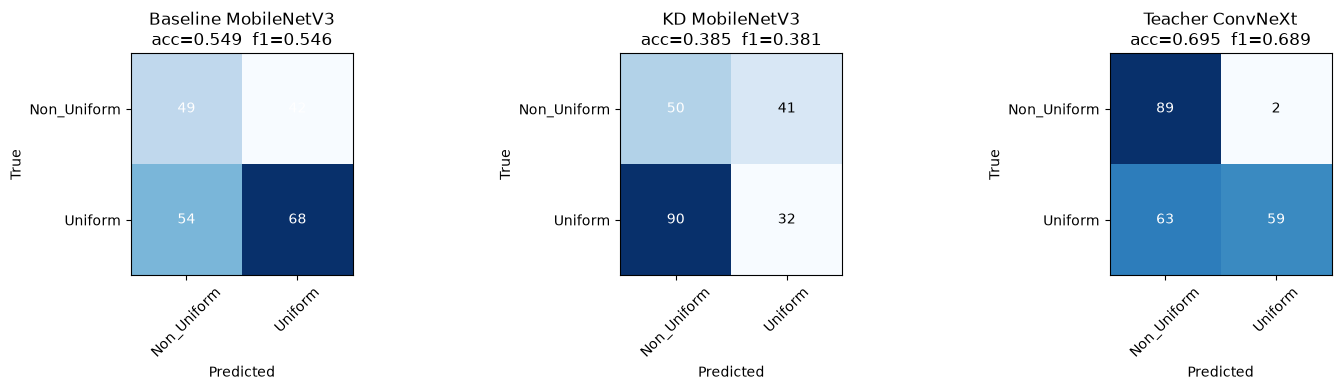

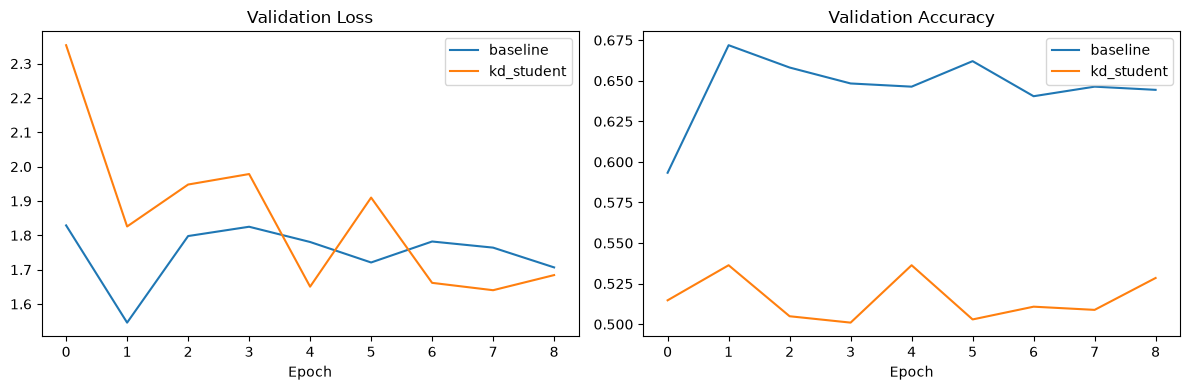

In [25]:
# --- Kết quả seed cuối cùng: confusion matrix + training curves ---
last = all_results[-1]
plot_confusion_matrices(
    {"Baseline MobileNetV3": last["baseline_metrics"],
     "KD MobileNetV3": last["kd_metrics"],
     "Teacher ConvNeXt": last["teacher_metrics"]},
    class_names=CFG.CLASS_NAMES,
)
plot_training_curves({
    "baseline": last["histories"]["baseline"],
    "kd_student": last["histories"]["kd_student"],
})


In [22]:
# --- Bảng tổng hợp mean +- std qua các seed (đáng tin cậy hơn 1 lần chạy đơn) ---
def summarize(all_results, key):
    accs = [r[key]["accuracy"] for r in all_results]
    f1s = [r[key]["f1_macro"] for r in all_results]
    return {
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "f1_macro_mean": float(np.mean(f1s)), "f1_macro_std": float(np.std(f1s)),
        "n_seeds": len(accs),
    }

summary = {
    "Teacher (ConvNeXt)": summarize(all_results, "teacher_metrics"),
    "Baseline (MobileNetV3)": summarize(all_results, "baseline_metrics"),
    "KD Student (MobileNetV3)": summarize(all_results, "kd_metrics"),
}

print(f"{'Model':<28}{'Accuracy':<22}{'F1-macro':<22}{'#seeds'}")
for name, s in summary.items():
    acc_str = f"{s['accuracy_mean']:.4f} +/- {s['accuracy_std']:.4f}"
    f1_str = f"{s['f1_macro_mean']:.4f} +/- {s['f1_macro_std']:.4f}"
    print(f"{name:<28}{acc_str:<22}{f1_str:<22}{s['n_seeds']}")

with open(os.path.join(CFG.OUTPUT_DIR, "summary_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nĐã lưu bảng tổng hợp tại: {os.path.join(CFG.OUTPUT_DIR, 'summary_metrics.json')}")


Model                       Accuracy              F1-macro              #seeds
Teacher (ConvNeXt)          0.6948 +/- 0.0000     0.6887 +/- 0.0000     1
Baseline (MobileNetV3)      0.5493 +/- 0.0000     0.5457 +/- 0.0000     1
KD Student (MobileNetV3)    0.3850 +/- 0.0000     0.3806 +/- 0.0000     1

Đã lưu bảng tổng hợp tại: ./runs/uniform_kd_experiment/summary_metrics.json


## Ghi chú khi phân tích kết quả

- Nếu KD vẫn thua baseline sau khi đổi teacher sang ConvNeXt: kiểm tra `teacher_metrics` trước —
  nếu teacher recall thấp ở một lớp (giống vấn đề bias của ViT trước đây), soft label vẫn sẽ nhiễu
  dù cùng họ CNN. Cân nhắc xử lý imbalance mạnh hơn ở tầng teacher hoặc tăng `KD_ALPHA`
  (giảm phụ thuộc vào soft label).
- Muốn thử feature-based KD: set `KD_LOSS_TYPE = "response+feature"` trong Config rồi bổ sung
  logic lấy intermediate feature map qua `timm`'s `forward_features()` — phần khung `kd_loss_fn`
  đã để sẵn chỗ để mở rộng.
- Để bài thẻ sinh viên dùng lại notebook này: đổi `DATA_ROOT` và `CLASS_NAMES` trong Config,
  không cần sửa gì khác.
